# K-Nearest Neighbours Classification — Zoo Animal Dataset
**Objective:** Implement and evaluate the KNN algorithm to classify animals into 7 types based on biological features.

---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded.')

All libraries loaded.


---
## Task 1 — Data Analysis and Visualizations

In [2]:
# Load dataset
df = pd.read_csv('Zoo.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (101, 18)


,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
5,buffalo,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
6,calf,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
7,carp,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,4
8,catfish,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
9,cavy,1,0,0,1,0,0,0,1,1,1,0,0,4,0,1,0,1


In [3]:
# Animal type mapping
type_map = {1: 'Mammal', 2: 'Bird', 3: 'Reptile',
            4: 'Fish', 5: 'Amphibian', 6: 'Bug', 7: 'Invertebrate'}
df['type_label'] = df['type'].map(type_map)

print('Dataset Info:')
print(f'  Rows    : {df.shape[0]}')
print(f'  Columns : {df.shape[1]}')
print(f'  Classes : {df["type"].nunique()} animal types')
print()
print('Class Distribution:')
print(df['type_label'].value_counts().to_string())

Dataset Info:
  Rows    : 101
  Columns : 19
  Classes : 7 animal types

Class Distribution:
type_label
Mammal          41
Bird            20
Fish            13
Invertebrate    10
Bug              8
Reptile          5
Amphibian        4


In [4]:
# Summary statistics
df.drop(columns=['animal name', 'type_label']).describe().round(3)

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000,101.000
mean,0.426,0.198,0.584,0.406,0.238,0.356,0.554,0.604,0.822,0.792,0.079,0.168,2.842,0.743,0.129,0.436,2.832
std,0.497,0.400,0.495,0.494,0.428,0.481,0.500,0.492,0.385,0.408,0.271,0.376,2.033,0.439,0.337,0.498,2.103
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,2.000,0.000,0.000,0.000,1.000
50%,0.000,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,0.000,0.000,4.000,1.000,0.000,0.000,2.000
75%,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,4.000,1.000,0.000,1.000,4.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,8.000,1.000,1.000,1.000,7.000


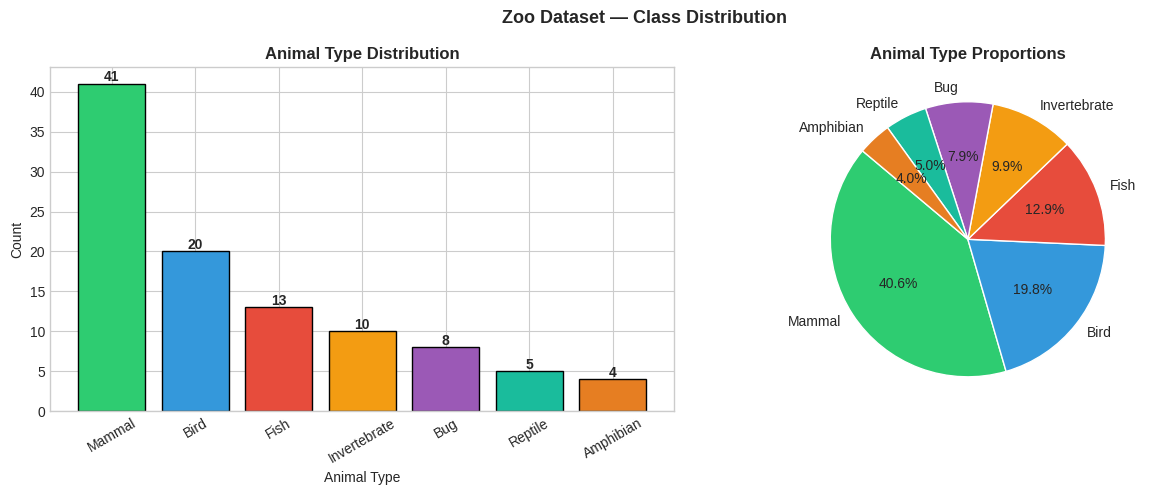

In [5]:
# --- Class Distribution ---
class_counts = df['type_label'].value_counts()
colors_class = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#1abc9c','#e67e22']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=colors_class, edgecolor='black')
for bar, v in zip(bars, class_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(v), ha='center', fontweight='bold')
axes[0].set_title('Animal Type Distribution', fontweight='bold')
axes[0].set_xlabel('Animal Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=colors_class, autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Animal Type Proportions', fontweight='bold')

plt.suptitle('Zoo Dataset — Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

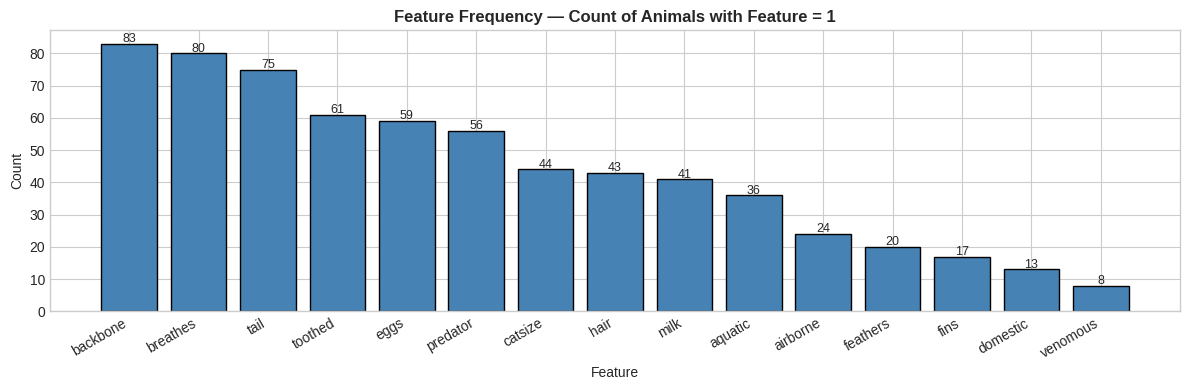

In [6]:
# --- Feature frequency (binary features) ---
bin_cols = ['hair','feathers','eggs','milk','airborne','aquatic',
            'predator','toothed','backbone','breathes','venomous',
            'fins','tail','domestic','catsize']

feat_sums = df[bin_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
bars = plt.bar(feat_sums.index, feat_sums.values, color='steelblue', edgecolor='black')
for bar, v in zip(bars, feat_sums.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             str(v), ha='center', fontsize=9)
plt.title('Feature Frequency — Count of Animals with Feature = 1', fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

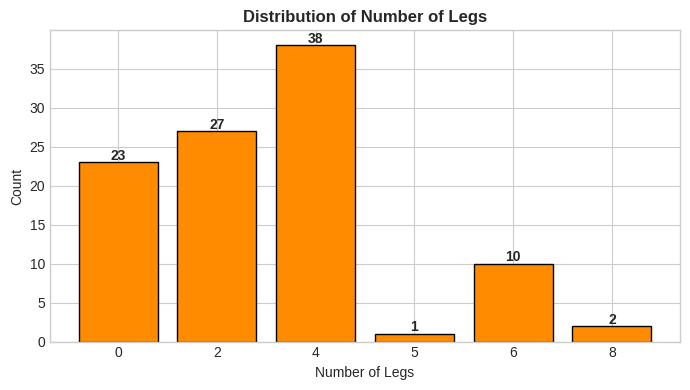

In [7]:
# --- Legs distribution ---
plt.figure(figsize=(7, 4))
leg_counts = df['legs'].value_counts().sort_index()
bars = plt.bar(leg_counts.index.astype(str), leg_counts.values,
               color='darkorange', edgecolor='black')
for bar, v in zip(bars, leg_counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             str(v), ha='center', fontweight='bold')
plt.title('Distribution of Number of Legs', fontweight='bold')
plt.xlabel('Number of Legs')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

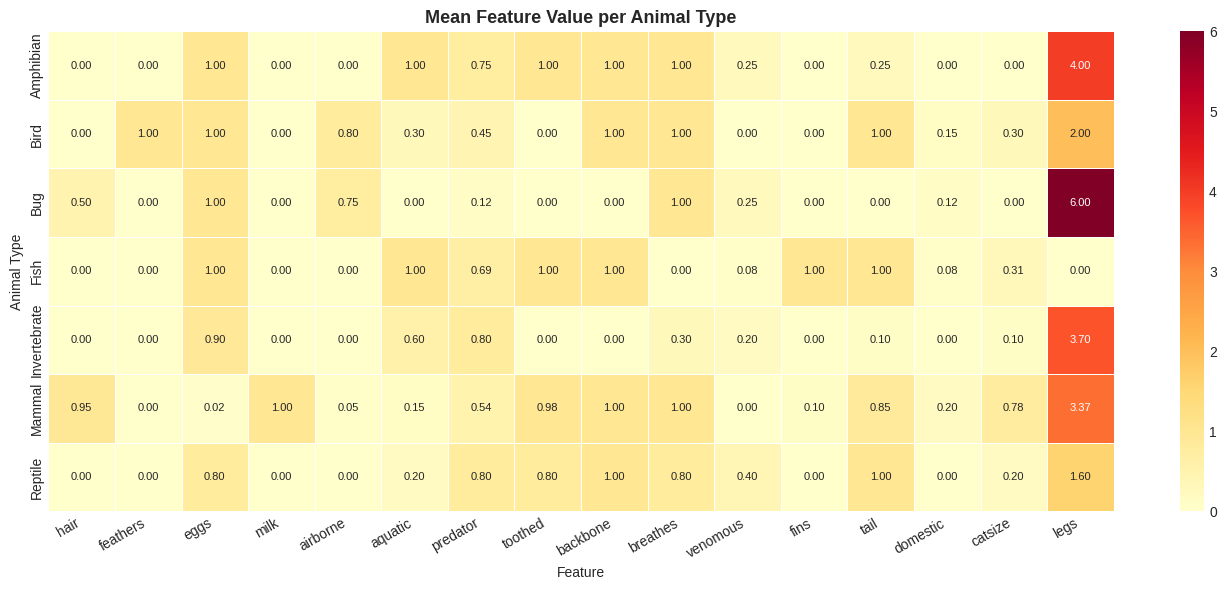

In [8]:
# --- Feature presence heatmap by animal type ---
feat_by_type = df.groupby('type_label')[bin_cols + ['legs']].mean()

plt.figure(figsize=(14, 6))
sns.heatmap(feat_by_type, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Mean Feature Value per Animal Type', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Animal Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

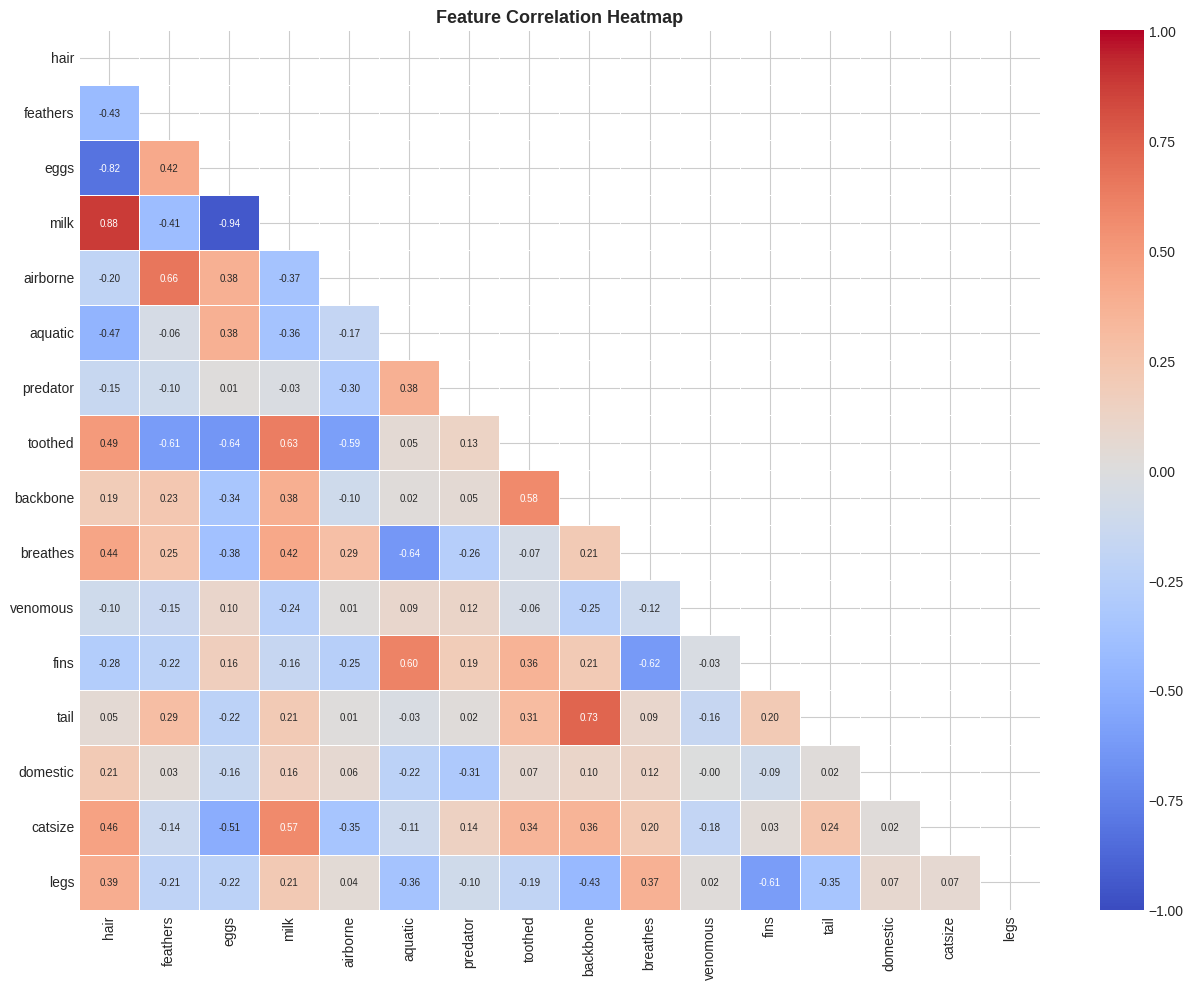

In [9]:
# --- Correlation heatmap ---
feat_cols_all = bin_cols + ['legs']
corr = df[feat_cols_all].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

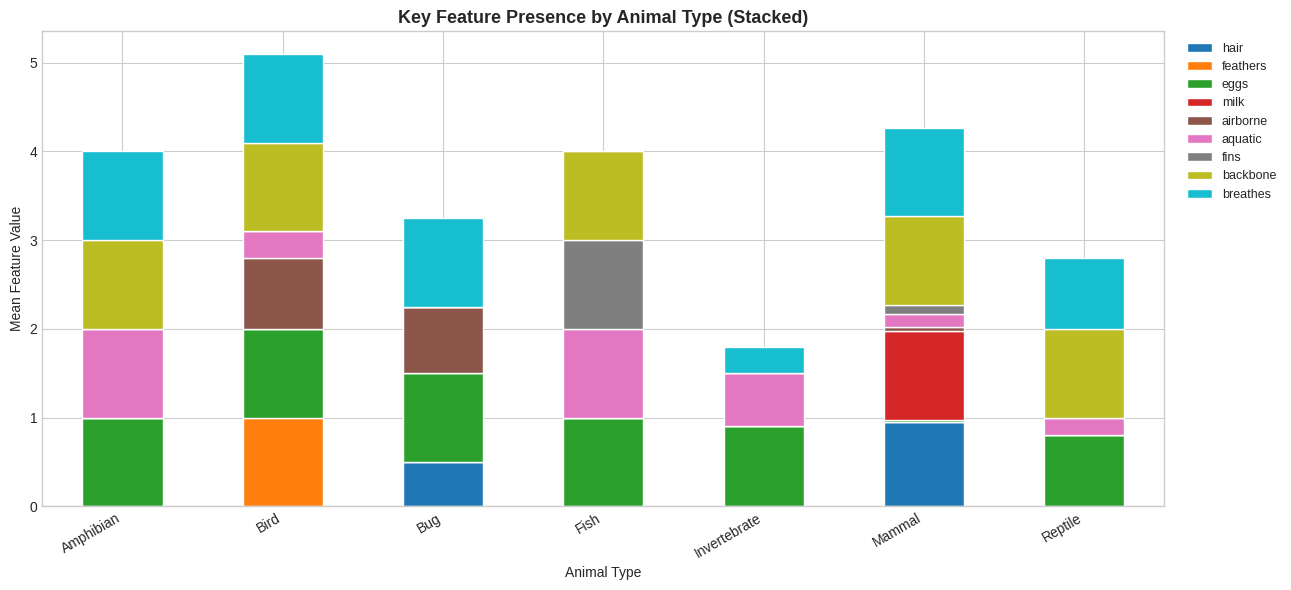

In [10]:
# --- Stacked bar: feature presence by type ---
key_feats = ['hair', 'feathers', 'eggs', 'milk', 'airborne',
             'aquatic', 'fins', 'backbone', 'breathes']
stacked = df.groupby('type_label')[key_feats].mean()

stacked.plot(kind='bar', stacked=True, figsize=(13, 6),
             colormap='tab10', edgecolor='white')
plt.title('Key Feature Presence by Animal Type (Stacked)', fontweight='bold', fontsize=13)
plt.xlabel('Animal Type')
plt.ylabel('Mean Feature Value')
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## Task 2 — Preprocessing: Missing Values & Outliers

In [11]:
# Missing values check
print('Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  No missing values found.')

Missing Values:
  No missing values found.


In [12]:
# Outlier detection — IQR on numerical features
# Most features are binary (0/1) — only 'legs' is truly continuous
print('Outlier Analysis (IQR Method):')
print('-' * 50)
for col in feat_cols_all:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        print(f'  {col:<12}: {n_out} outliers  (fence: [{lower:.2f}, {upper:.2f}])')
print()
print('Note: Binary features (0/1) have no meaningful outliers.')
print('Legs values [0,2,4,5,6,8] are valid biological categories — retained as-is.')

Outlier Analysis (IQR Method):
--------------------------------------------------
  feathers    : 20 outliers  (fence: [0.00, 0.00])
  airborne    : 24 outliers  (fence: [0.00, 0.00])
  backbone    : 18 outliers  (fence: [1.00, 1.00])
  breathes    : 21 outliers  (fence: [1.00, 1.00])
  venomous    : 8 outliers  (fence: [0.00, 0.00])
  fins        : 17 outliers  (fence: [0.00, 0.00])
  domestic    : 13 outliers  (fence: [0.00, 0.00])
  legs        : 2 outliers  (fence: [-1.00, 7.00])

Note: Binary features (0/1) have no meaningful outliers.
Legs values [0,2,4,5,6,8] are valid biological categories — retained as-is.


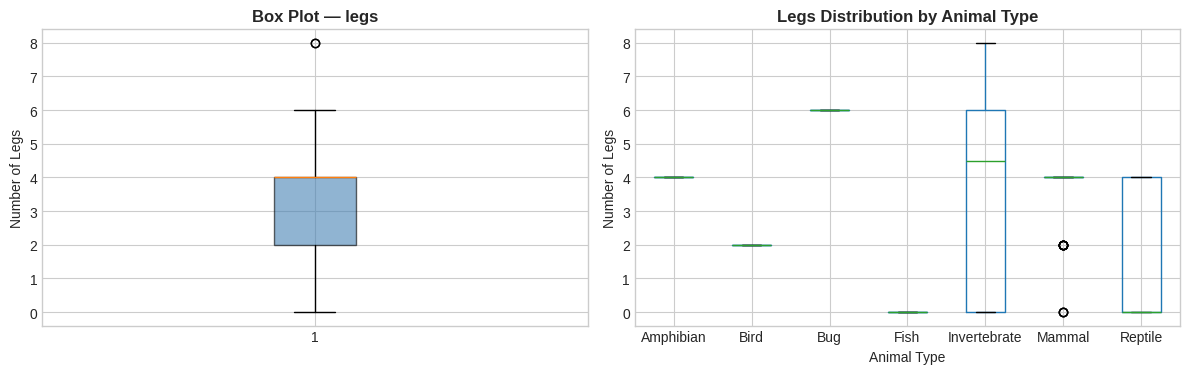

No outliers removed — all values are biologically valid.


In [13]:
# Box plots for legs (only non-binary feature)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['legs'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Box Plot — legs', fontweight='bold')
axes[0].set_ylabel('Number of Legs')

df.boxplot(column='legs', by='type_label', ax=axes[1])
axes[1].set_title('Legs Distribution by Animal Type', fontweight='bold')
axes[1].set_xlabel('Animal Type')
axes[1].set_ylabel('Number of Legs')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('No outliers removed — all values are biologically valid.')

In [14]:
# Prepare features and target
X = df[feat_cols_all].copy()   # 15 binary + legs
y = df['type'].copy()

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Features used:', feat_cols_all)

Feature matrix shape: (101, 16)
Target shape: (101,)
Features used: ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'tail', 'domestic', 'catsize', 'legs']


---
## Task 3 — Train-Test Split (80 / 20)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total samples   : {len(X)}')
print(f'Training set    : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Testing set     : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Training class distribution:')
print(y_train.map(type_map).value_counts().to_string())
print()
print('Testing class distribution:')
print(y_test.map(type_map).value_counts().to_string())

Total samples   : 101
Training set    : 80 (79%)
Testing set     : 21 (21%)

Training class distribution:
type
Mammal          33
Bird            16
Fish            10
Invertebrate     8
Bug              6
Reptile          4
Amphibian        3

Testing class distribution:
type
Mammal          8
Bird            4
Fish            3
Bug             2
Invertebrate    2
Amphibian       1
Reptile         1


In [16]:
# Scale features — important for KNN (distance-based)
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Features scaled with StandardScaler.')

Features scaled with StandardScaler.


---
## Task 4 — Implement KNN

In [17]:
# Find best K using cross-validation on training set
k_range   = range(1, 21)
cv_scores = []
train_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    cv  = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())
    knn.fit(X_train_sc, y_train)
    train_scores.append(knn.score(X_train_sc, y_train))

best_k = k_range[np.argmax(cv_scores)]
print(f'Best K (by 5-fold CV accuracy) = {best_k}')
print(f'Best CV Accuracy = {max(cv_scores):.4f}')

Best K (by 5-fold CV accuracy) = 1
Best CV Accuracy = 0.9375


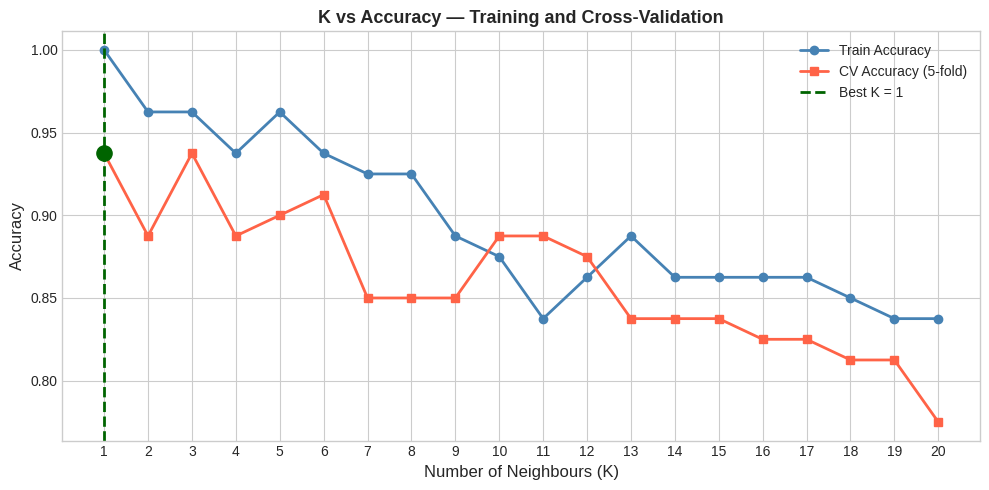

In [18]:
# Plot K vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), train_scores, 'o-', color='steelblue',
         linewidth=2, label='Train Accuracy')
plt.plot(list(k_range), cv_scores, 's-', color='tomato',
         linewidth=2, label='CV Accuracy (5-fold)')
plt.axvline(best_k, color='darkgreen', linestyle='--', linewidth=2,
            label=f'Best K = {best_k}')
plt.scatter([best_k], [max(cv_scores)], color='darkgreen', s=120, zorder=5)
plt.xlabel('Number of Neighbours (K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('K vs Accuracy — Training and Cross-Validation', fontsize=13, fontweight='bold')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Train final KNN model with best K
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='uniform')
knn_final.fit(X_train_sc, y_train)
print(f'KNN model trained with K={best_k}, metric=euclidean')

KNN model trained with K=1, metric=euclidean


---
## Task 5 — Distance Metric and K Selection

In [20]:
# Compare multiple distance metrics
metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
metric_results = {}

for metric in metrics:
    scores = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        cv  = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy')
        scores.append(cv.mean())
    best_k_m  = list(k_range)[np.argmax(scores)]
    best_acc  = max(scores)
    metric_results[metric] = {'best_k': best_k_m, 'best_acc': best_acc, 'scores': scores}
    print(f'{metric:<12} → Best K: {best_k_m:>2}  |  Best CV Accuracy: {best_acc:.4f}')

euclidean    → Best K:  1  |  Best CV Accuracy: 0.9375


manhattan    → Best K:  1  |  Best CV Accuracy: 0.9500


chebyshev    → Best K:  1  |  Best CV Accuracy: 0.8500


minkowski    → Best K:  1  |  Best CV Accuracy: 0.9375


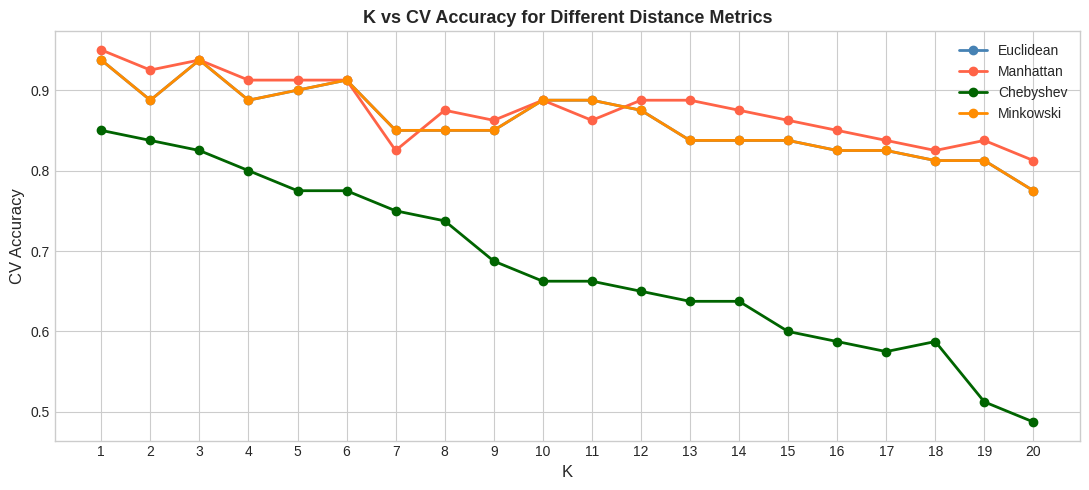

In [21]:
# Plot K vs CV accuracy for all metrics
plt.figure(figsize=(11, 5))
metric_colors = ['steelblue', 'tomato', 'darkgreen', 'darkorange']
for metric, color in zip(metrics, metric_colors):
    plt.plot(list(k_range), metric_results[metric]['scores'],
             'o-', color=color, linewidth=2, label=metric.capitalize())
plt.xlabel('K', fontsize=12)
plt.ylabel('CV Accuracy', fontsize=12)
plt.title('K vs CV Accuracy for Different Distance Metrics', fontsize=13, fontweight='bold')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Best metric summary
best_metric = max(metric_results, key=lambda m: metric_results[m]['best_acc'])
best_k_final = metric_results[best_metric]['best_k']
print(f'Best Distance Metric : {best_metric}')
print(f'Best K               : {best_k_final}')
print(f'Best CV Accuracy     : {metric_results[best_metric]["best_acc"]:.4f}')

# Retrain with best metric
knn_best = KNeighborsClassifier(n_neighbors=best_k_final, metric=best_metric)
knn_best.fit(X_train_sc, y_train)
print(f'\nFinal model: KNN(K={best_k_final}, metric={best_metric})')

Best Distance Metric : manhattan
Best K               : 1
Best CV Accuracy     : 0.9500

Final model: KNN(K=1, metric=manhattan)


---
## Task 6 — Evaluate Performance on Test Set

In [23]:
y_pred = knn_best.predict(X_test_sc)
y_pred_labels = [type_map[v] for v in y_pred]
y_test_labels = [type_map[v] for v in y_test]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('=' * 55)
print('KNN PERFORMANCE ON TEST SET')
print('=' * 55)
print(f'  K               : {best_k_final}')
print(f'  Distance Metric : {best_metric}')
print(f'  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision       : {prec:.4f}  (weighted avg)')
print(f'  Recall          : {rec:.4f}  (weighted avg)')
print(f'  F1-Score        : {f1:.4f}  (weighted avg)')
print('=' * 55)

KNN PERFORMANCE ON TEST SET
  K               : 1
  Distance Metric : manhattan
  Accuracy        : 1.0000  (100.00%)
  Precision       : 1.0000  (weighted avg)
  Recall          : 1.0000  (weighted avg)
  F1-Score        : 1.0000  (weighted avg)


In [24]:
# Detailed classification report
type_order = [type_map[i] for i in sorted(type_map)]
print('Classification Report:')
print(classification_report(y_test_labels, y_pred_labels,
                             target_names=type_order,
                             zero_division=0))

Classification Report:
              precision    recall  f1-score   support

      Mammal       1.00      1.00      1.00         1
        Bird       1.00      1.00      1.00         4
     Reptile       1.00      1.00      1.00         2
        Fish       1.00      1.00      1.00         3
   Amphibian       1.00      1.00      1.00         2
         Bug       1.00      1.00      1.00         8
Invertebrate       1.00      1.00      1.00         1

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



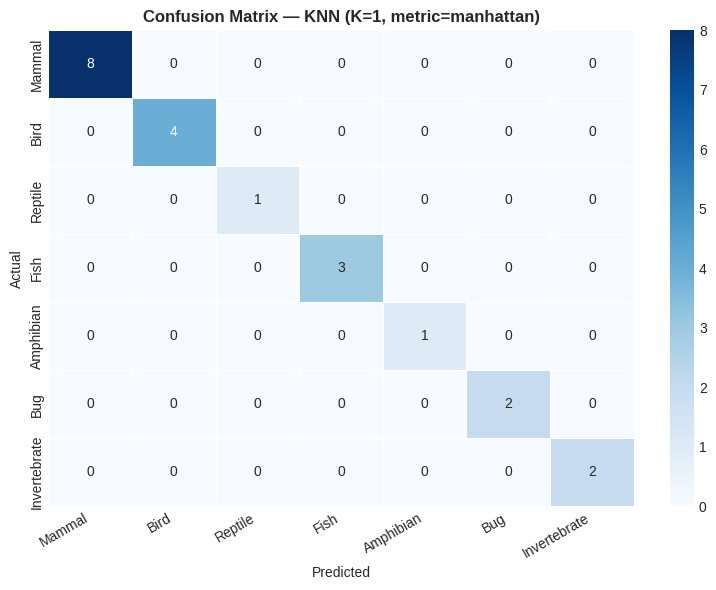

In [25]:
# Confusion Matrix
type_order_vals = sorted(type_map.keys())
type_order_labs = [type_map[v] for v in type_order_vals]
cm = confusion_matrix(y_test, y_pred, labels=type_order_vals)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=type_order_labs,
            yticklabels=type_order_labs,
            linewidths=0.5)
plt.title(f'Confusion Matrix — KNN (K={best_k_final}, metric={best_metric})',
          fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

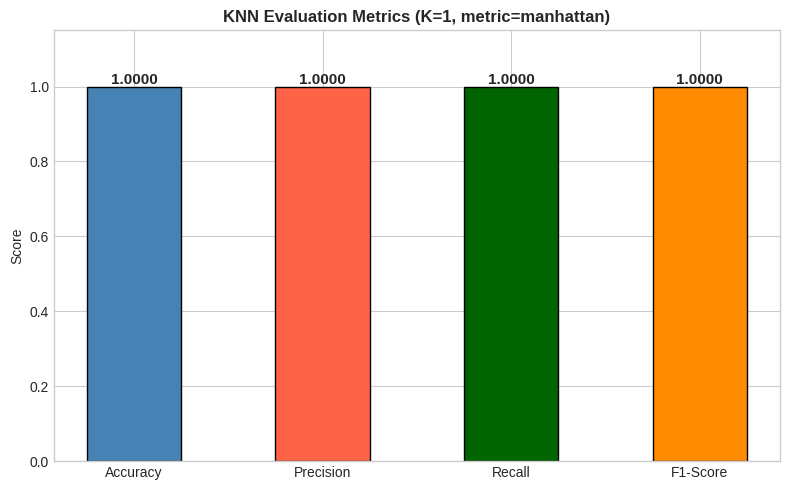

In [26]:
# Metrics comparison bar chart
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [acc, prec, rec, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values,
               color=['steelblue','tomato','darkgreen','darkorange'],
               edgecolor='black', width=0.5)
for bar, v in zip(bars, metric_values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.ylim(0, 1.15)
plt.title(f'KNN Evaluation Metrics (K={best_k_final}, metric={best_metric})',
          fontweight='bold')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

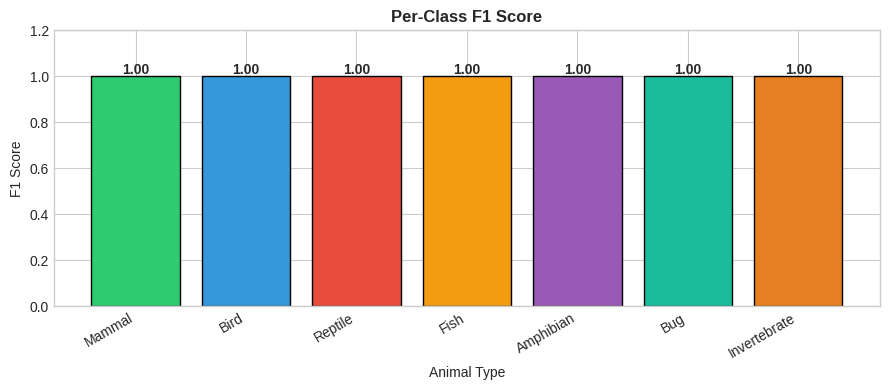

In [27]:
# Per-class F1 scores
f1_per_class = f1_score(y_test, y_pred, average=None,
                        labels=type_order_vals, zero_division=0)

plt.figure(figsize=(9, 4))
bars = plt.bar(type_order_labs, f1_per_class,
               color=colors_class, edgecolor='black')
for bar, v in zip(bars, f1_per_class):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{v:.2f}', ha='center', fontweight='bold')
plt.title('Per-Class F1 Score', fontweight='bold')
plt.ylabel('F1 Score')
plt.xlabel('Animal Type')
plt.ylim(0, 1.2)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## Task 7 — Visualize Decision Boundaries (PCA 2D)

In [28]:
# PCA: reduce to 2D for decision boundary visualization
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d  = pca.transform(X_test_sc)

print(f'PCA Explained Variance Ratio: {pca.explained_variance_ratio_.round(4)}')
print(f'Total Variance Explained     : {pca.explained_variance_ratio_.sum()*100:.2f}%')

PCA Explained Variance Ratio: [0.288  0.2129]
Total Variance Explained     : 50.10%


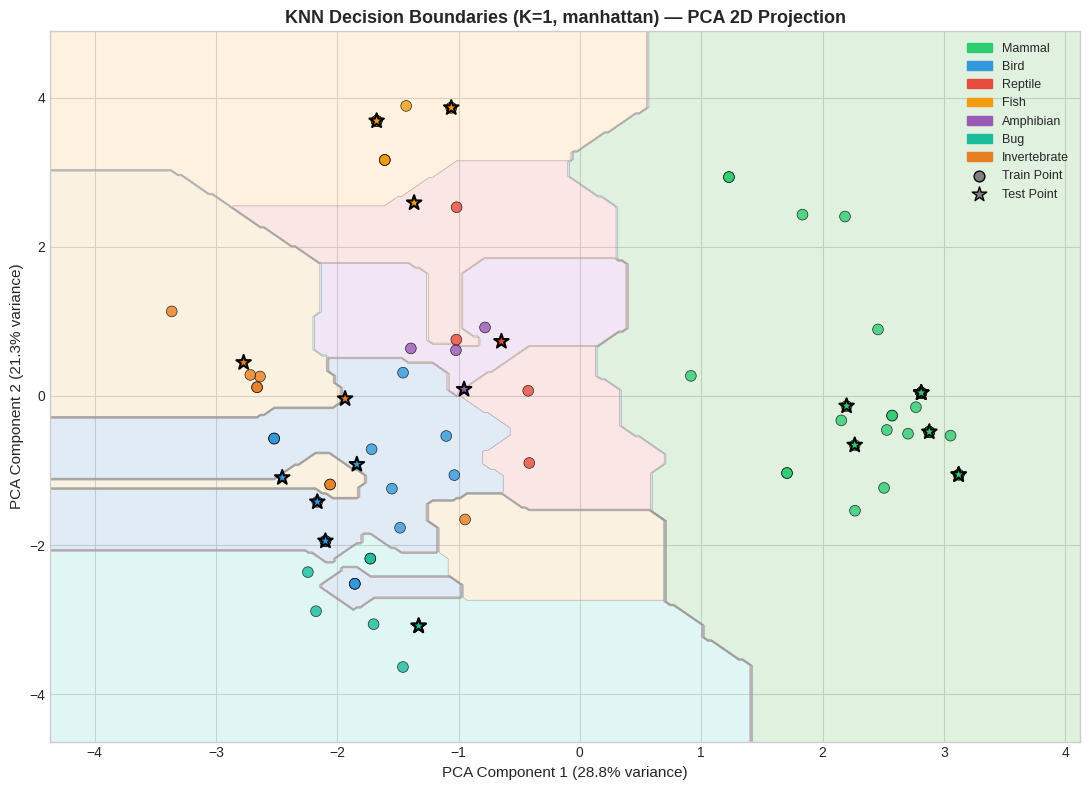

In [29]:
# Train KNN on 2D PCA features for boundary plot
knn_2d = KNeighborsClassifier(n_neighbors=best_k_final, metric=best_metric)
knn_2d.fit(X_train_2d, y_train)

# Create mesh grid
x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1
y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Color map
from matplotlib.colors import ListedColormap
class_vals = sorted(type_map.keys())
cmap_bg   = ListedColormap(['#a8d8a8','#a8c8e8','#f5b8b8','#ffd8a8',
                             '#d8b8e8','#a8e8e0','#f5d8a8'])
cmap_pts  = ListedColormap(['#2ecc71','#3498db','#e74c3c','#f39c12',
                             '#9b59b6','#1abc9c','#e67e22'])

plt.figure(figsize=(11, 8))
plt.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg,
             levels=np.arange(0.5, 8.5, 1))
plt.contour(xx, yy, Z, colors='gray', linewidths=0.5,
            levels=np.arange(0.5, 8.5, 1), alpha=0.5)

# Plot training points
sc_train = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                       c=[class_vals.index(v)+1 for v in y_train],
                       cmap=cmap_pts, s=60, edgecolors='black',
                       linewidths=0.5, zorder=3, alpha=0.8, marker='o',
                       label='Train')
# Plot test points
sc_test  = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                       c=[class_vals.index(v)+1 for v in y_test],
                       cmap=cmap_pts, s=120, edgecolors='black',
                       linewidths=1.5, zorder=4, marker='*')

# Legend
legend_patches = [
    mpatches.Patch(color=cmap_pts(i/6), label=type_map[v])
    for i, v in enumerate(class_vals)
]
train_handle = plt.scatter([], [], marker='o', color='gray',
                            edgecolors='black', s=60, label='Train Point')
test_handle  = plt.scatter([], [], marker='*', color='gray',
                            edgecolors='black', s=120, label='Test Point')
plt.legend(handles=legend_patches + [train_handle, test_handle],
           loc='upper right', fontsize=9)

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
plt.title(f'KNN Decision Boundaries (K={best_k_final}, {best_metric}) — PCA 2D Projection',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

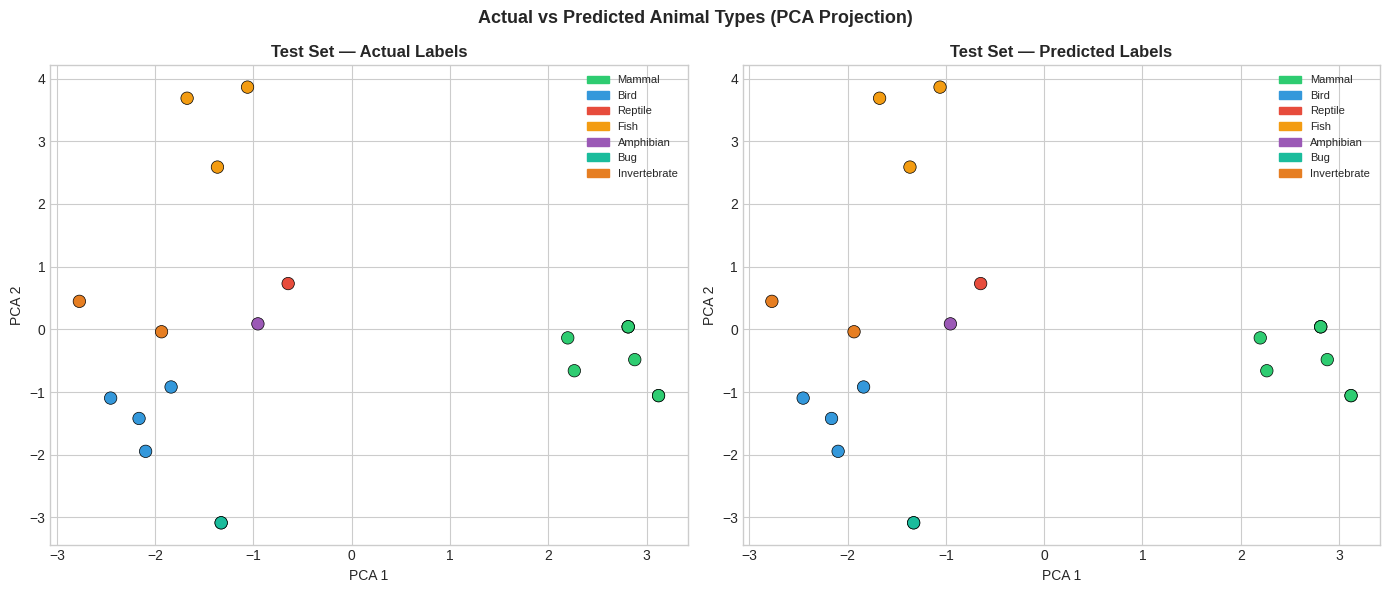

In [30]:
# Actual vs Predicted scatter (PCA 2D)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, labels, title in zip(axes,
                              [y_test.values, y_pred],
                              ['Actual Labels', 'Predicted Labels']):
    colors_pts = [colors_class[class_vals.index(v)] for v in labels]
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
               c=colors_pts, s=80, edgecolors='black', linewidths=0.5)
    ax.set_title(f'Test Set — {title}', fontweight='bold')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    patches = [mpatches.Patch(color=colors_class[i], label=type_map[v])
               for i, v in enumerate(class_vals)]
    ax.legend(handles=patches, fontsize=8, loc='upper right')

plt.suptitle('Actual vs Predicted Animal Types (PCA Projection)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Interview Questions

### Q1. What are the key hyperparameters in KNN?

| Hyperparameter | Description | Effect |
|---|---|---|
| **K (n_neighbors)** | Number of nearest neighbours to vote | Small K → complex boundary, prone to overfitting; Large K → smooth boundary, may underfit |
| **metric** | Distance metric used to measure similarity | Determines how "nearness" is computed — different metrics suit different data distributions |
| **weights** | `'uniform'` (equal vote) or `'distance'` (closer neighbours weigh more) | `distance` weighting helps when nearby points are more relevant than farther ones |
| **algorithm** | `'ball_tree'`, `'kd_tree'`, `'brute'` | Affects speed of neighbour search; `kd_tree` efficient for low dimensions, `brute` for small datasets |
| **p** | Power parameter for Minkowski metric | p=1 → Manhattan, p=2 → Euclidean |
| **leaf_size** | Leaf size for BallTree / KDTree | Affects query speed and memory; larger leaf_size → faster but less accurate |

**Most impactful:** K and metric. Always select K using cross-validation rather than fixed guesses.

---

### Q2. What distance metrics can be used in KNN?

| Metric | Formula | Best Used When |
|---|---|---|
| **Euclidean** | √Σ(xᵢ − yᵢ)² | Continuous features, isotropic distributions (most common default) |
| **Manhattan** | Σ\|xᵢ − yᵢ\| | High-dimensional data; robust to outliers; good for city-block type problems |
| **Minkowski** | (Σ\|xᵢ − yᵢ\|^p)^(1/p) | Generalisation — controls Euclidean (p=2) and Manhattan (p=1) via parameter p |
| **Chebyshev** | max(\|xᵢ − yᵢ\|) | When the maximum coordinate difference is the most critical dimension |
| **Hamming** | Proportion of differing positions | Binary or categorical features (e.g., this Zoo dataset's 0/1 features) |
| **Cosine** | 1 − (A·B)/(\|A\|\|B\|) | Text/NLP data; when magnitude doesn't matter, only direction/angle does |
| **Mahalanobis** | Accounts for feature correlations and scale | When features are correlated; removes need for separate scaling |

**For this dataset:** Euclidean (after scaling) works well because most features are binary 0/1. Hamming distance is also theoretically ideal for binary feature vectors.

In [31]:
# Final summary
print('=' * 55)
print('FINAL SUMMARY')
print('=' * 55)
print(f'Dataset          : Zoo.csv (101 animals, 7 types)')
print(f'Features used    : {len(feat_cols_all)}')
print(f'Best K           : {best_k_final}')
print(f'Best Metric      : {best_metric}')
print(f'Train size       : {len(X_train)}')
print(f'Test size        : {len(X_test)}')
print()
print(f'Accuracy         : {acc:.4f}')
print(f'Precision        : {prec:.4f}')
print(f'Recall           : {rec:.4f}')
print(f'F1-Score         : {f1:.4f}')
print('=' * 55)

FINAL SUMMARY
Dataset          : Zoo.csv (101 animals, 7 types)
Features used    : 16
Best K           : 1
Best Metric      : manhattan
Train size       : 80
Test size        : 21

Accuracy         : 1.0000
Precision        : 1.0000
Recall           : 1.0000
F1-Score         : 1.0000
